# K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a **Supervised Machine Learning Algorithm**.

It can be used for:

- Classification ✅
- Regression ✅

Most commonly, it is used for **classification**.

Examples:

- Disease Prediction
- Iris Flower Classification
- Handwritten Digit Recognition
- Recommendation Systems
- Customer Classification

---

# Intuition

KNN makes predictions based on the **nearest neighbors**.

It asks:

> **"Who are my closest neighbors?"**

Then it lets those neighbors decide the prediction.

---

# Example

Suppose we have two classes.

```
● = Apple

▲ = Orange

                 ▲
          ▲

      ●

             ?

  ●

        ●
```

The new point is **?**

KNN looks around the point and finds its nearest neighbors.

---

# K = 3

```
                 ▲
          ▲

      ●

          ?


  ●

        ●
```

Nearest neighbors

```
●
●
▲
```

Voting

```
Apple  = 2

Orange = 1
```

Prediction

```
?

↓

Apple
```

---

# K = 5

```
                 ▲
          ▲

      ●

          ?

  ●

        ●
```

Nearest neighbors

```
●
●
●
▲
▲
```

Voting

```
Apple = 3

Orange = 2
```

Prediction

```
Apple
```

---

# How KNN Works

```
Training Data
      │
      ▼
Store Entire Dataset
      │
      ▼
New Data Point
      │
      ▼
Calculate Distance
      │
      ▼
Find K Nearest Points
      │
      ▼
Majority Voting
      │
      ▼
Prediction
```

---

# Why is it called Lazy Learning?

Most algorithms learn during training.

KNN does **not**.

```
Training

↓

Just stores the data

↓

Prediction Time

↓

Calculates everything
```

So KNN is called a **Lazy Learner**.

---

# Distance Metrics

KNN decides neighbors using **distance**.

Most common:

## 1. Euclidean Distance

Straight-line distance.

```
A ●

 \
  \
   \
    ● B
```

Formula

$$
d
=
\sqrt{
(x_2-x_1)^2
+
(y_2-y_1)^2
}
$$

Most commonly used.

---

## 2. Manhattan Distance

Moves only horizontally and vertically.

```
●───┐
    │
    │
    ●
```

Formula

$$
d
=
|x_2-x_1|
+
|y_2-y_1|
$$

---

## 3. Minkowski Distance

Generalized distance.

Euclidean and Manhattan are special cases.

---

# Choosing K

Choosing K is very important.

---

## Small K

Example

```
K = 1
```

```
      ▲

   ?

●
```

Prediction depends on only one neighbor.

Very sensitive to noise.

May overfit.

---

## Large K

Example

```
K = 25
```

Uses many neighbors.

```
Many neighbors

↓

Smooth boundary

↓

May underfit
```

---

# Rule of Thumb

```
Small K

↓

Overfitting
```

```
Large K

↓

Underfitting
```

Usually start with

```python
n_neighbors = 5
```

Then tune using cross-validation.

---

# Choosing the Best K

Use GridSearchCV.

```python
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

params = {
    "n_neighbors":[3,5,7,9,11]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)
```

---

# Why Feature Scaling is Important

Suppose we have

```
Age

25

Salary

900000
```

Without scaling

```
Salary dominates the distance.
```

Distance becomes meaningless.

Always use

```python
StandardScaler()
```

before KNN.

---

# Scikit-Learn Syntax

```python
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(
    n_neighbors=5
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
```

---

# Important Hyperparameters

## 1. n_neighbors

Number of neighbors.

```python
n_neighbors=5
```

Most important hyperparameter.

---

## 2. weights

```python
weights="uniform"
```

Possible values

```
uniform

distance
```

### uniform

Every neighbor gets equal vote.

```
●

▲

●
```

Each vote = 1

---

### distance

Closer neighbors get more importance.

```
Near

Vote = 5

Far

Vote = 1
```

Usually performs better.

---

## 3. metric

Distance metric.

```python
metric="minkowski"
```

Possible values

```
euclidean

manhattan

minkowski
```

---

# Hyperparameter Tuning

```python
params = {
    "n_neighbors":[3,5,7,9],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}
```

---

# Classification vs Regression

Classification

```
Voting
```

Regression

```
Average of neighbors
```

Example

Neighbors

```
100

110

120
```

Prediction

```
110
```

---

# Advantages

✅ Simple

✅ No training time

✅ Easy to understand

✅ Works well on small datasets

✅ Can model complex decision boundaries

---

# Disadvantages

❌ Slow prediction

❌ Sensitive to feature scaling

❌ Sensitive to irrelevant features

❌ Uses a lot of memory

❌ Struggles with very large datasets

---

# When Should We Use KNN?

Use KNN when

- Dataset is small
- Features are scaled
- Decision boundary is complex
- Fast training is required

Examples

- Heart Disease Prediction
- Customer Classification
- Recommendation Systems
- Pattern Recognition

---

# When Should We Avoid KNN?

Avoid when

- Dataset is very large
- Many irrelevant features
- High-dimensional data
- Fast prediction is required

---

# Comparison

| Algorithm | Training | Prediction | Scaling Needed |
|-----------|----------|------------|----------------|
| Logistic Regression | Fast | Fast | Yes |
| SVM | Medium | Medium | Yes |
| Naive Bayes | Fast | Fast | Usually No |
| KNN | Almost None | Slow | **Yes** |

---

# Rule of Thumb

```
Linear Relationship?

↓

Logistic Regression
```

```
Complex Boundary?

↓

KNN
```

```
Text Classification?

↓

Naive Bayes
```

```
Maximum Margin?

↓

SVM
```

---

# One-Line Definition

> **K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that predicts the class (or value) of a new data point by looking at the K closest training samples using a distance metric such as Euclidean distance.**

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import make_classification

In [3]:
X, y = make_classification(
    n_samples= 100,
    n_features= 3,
    n_redundant= 1,
    n_classes= 2,
    random_state= 42
)

In [4]:
X

array([[ 1.19664076,  1.19520687, -0.80804463],
       [-0.35885569, -0.81522223,  1.65214494],
       [-0.38919817, -0.79145712,  1.50575249],
       [ 1.09180466,  0.46971052,  1.17869556],
       [ 2.30450019,  1.20138599,  1.83991037],
       [-1.79532002, -1.48271828,  0.25415746],
       [-1.05383855, -1.0896397 ,  0.82600732],
       [-2.25553963, -1.67166027, -0.27062383],
       [-0.04862909,  0.66551093, -2.17105282],
       [-1.00544254, -1.13632294,  1.08659413],
       [-1.32933233, -1.24016884,  0.6273745 ],
       [-1.56826626, -0.76726727, -1.40735658],
       [ 0.36016958,  0.84963353, -1.75518644],
       [-1.26898369, -0.59855594, -1.20757158],
       [ 2.38869353,  1.68194689,  0.55942643],
       [-1.14658127, -1.17052885,  0.85239186],
       [ 1.4991983 ,  0.65993835,  1.57233676],
       [ 0.49429823,  0.36247661,  0.07123641],
       [ 1.02703224,  0.5805838 ,  0.68057323],
       [ 2.25661188,  0.99270816,  2.36867367],
       [ 1.48052803,  1.31953183, -0.508

___
# Train Test split

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.30, random_state= 42)

___
# Model Training

In [7]:
from sklearn.neighbors import KNeighborsClassifier

In [8]:
# by default K = 5
# p = 1 :: Manhattan distance ,  p = 2 :: ecildean distance
# algirithn = Balltree or KDtree


classifier = KNeighborsClassifier(n_neighbors=5, algorithm='auto')

classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [9]:
y_pred = classifier.predict(X_test)

___
# MEtrics

In [10]:
from sklearn.metrics import accuracy_score, classification_report

In [11]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9666666666666667
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.94      0.97        18

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



___
# Choosing the best k value
___

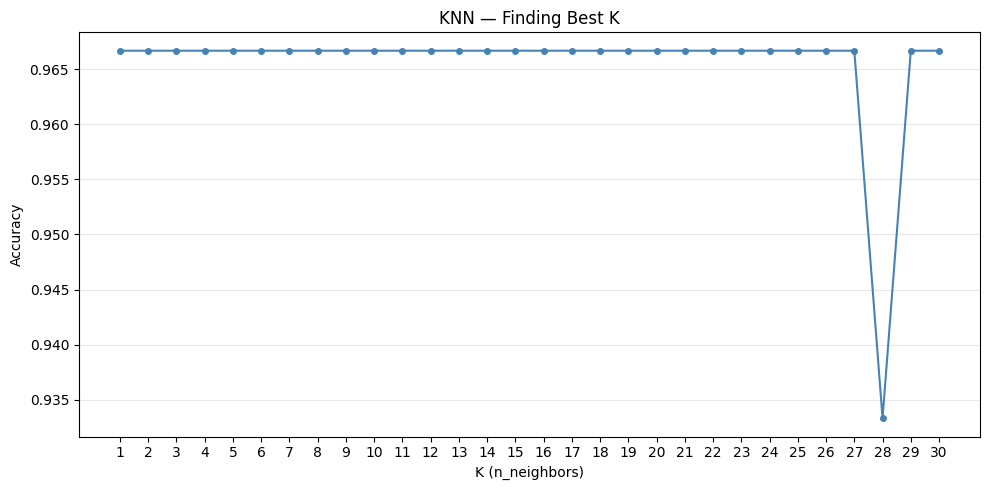

Best K = 1  →  Accuracy = 0.9667


In [18]:
# the most important hyperparameter in KNN is K (n_neighbors)
# K too small (1-2) → overfits — memorizes noise
# K too large (50+) → underfits — ignores local patterns
# sweet spot is usually somewhere between 3 and 20

k_range = range(1, 31)
scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    score = accuracy_score(y_test, knn_temp.predict(X_test))
    scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, scores, marker="o", color="steelblue", markersize=4)
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN — Finding Best K")
plt.xticks(range(1, 31))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(scores)]
print(f"Best K = {best_k}  →  Accuracy = {max(scores):.4f}")

___
# Hyper Parameter Tuning 
___

```
___
## KNN Hyperparameters

### n_neighbors (K)
    How many nearest neighbors to consider
    K=1  → only 1 closest point votes → overfits
    K=5  → 5 closest points vote → default, usually good
    K=20 → 20 points vote → smoother but might miss local patterns

### weights
    "uniform"  → all K neighbors have equal vote (default)
    "distance" → closer neighbors have MORE influence than farther ones
    
    Example with K=5 :
    uniform  → 3 benign + 2 malignant → predict benign (3>2)
    distance → if the 2 malignant are VERY close and 3 benign are far
              → the 2 close malignant might outweigh → predict malignant

### metric (distance formula)
    "euclidean"  → straight line distance (default) → most common
    "manhattan"  → city block distance (sum of absolute differences)
    "minkowski"  → general formula — p=2 is euclidean, p=1 is manhattan

### p
    Only used when metric="minkowski"
    p=1 → manhattan distance
    p=2 → euclidean distance (default)

### algorithm
    "auto"      → sklearn picks the best (default)
    "ball_tree" → faster for high dimensional data
    "kd_tree"   → faster for low dimensional data
    "brute"     → checks every single point — slowest but works always
___

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [13]:


params = {
    "n_neighbors" : [3,5,7,9,11],
    "weights" : ["uniform", "distance"],
    "metric" : ["euclidean", "manhattan"],
    "algorithm" : ["ball_tree", "kd_tree", "brute", "auto"],
    "p" : [1,2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
model_tuned = GridSearchCV(
    estimator=KNeighborsClassifier(), 
    param_grid=params, 
    cv = cv,
    scoring="accuracy",
    n_jobs=-1)

In [15]:
model_tuned.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['ball_tree', 'kd_tree', ...], 'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'p': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [16]:
model_tuned.best_params_

{'algorithm': 'ball_tree',
 'metric': 'euclidean',
 'n_neighbors': 5,
 'p': 1,
 'weights': 'uniform'}

In [17]:
model_tuned.best_score_

np.float64(0.9857142857142858)